# Training Progress Analysis

Reads `ckpt_hubert_multitask/result.csv` and produces:
- Train loss curve (per step)
- Validation loss + Pearson / Spearman / MAE curves (per epoch)
- Per-dimension breakdown at best checkpoint
- Convergence summary table

## 0 · Config

In [ ]:
CSV_PATH  = "ckpt_hubert_multitask/result.csv"
BEST_METRIC = "pearson_total"          # metric used to pick best epoch
SENT_DIMS   = ["total", "accuracy", "fluency"]

## 1 · Load & split

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

df = pd.read_csv(CSV_PATH)
df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
df["step"]  = pd.to_numeric(df["step"],  errors="coerce")

train = df[df["phase"] == "train"].copy()
val   = df[df["phase"] == "val"].copy().reset_index(drop=True)

# Global step index for x-axis of training curve
train["global_step"] = range(len(train))

print(f"Train rows : {len(train)}")
print(f"Val rows   : {len(val)}   ({val['epoch'].min():.0f} – {val['epoch'].max():.0f} epochs)")
print(f"Columns    : {list(df.columns)}")

Train rows : 1200
Val rows   : 100   (1 – 100 epochs)
Columns    : ['epoch', 'step', 'phase', 'train_loss', 'loss_sent', 'loss_prosody', 'val_loss', 'mae_total', 'mae_accuracy', 'mae_fluency', 'mae_prosodic', 'mae_completeness', 'rmse_total', 'rmse_accuracy', 'rmse_fluency', 'rmse_prosodic', 'rmse_completeness', 'pearson_total', 'pearson_accuracy', 'pearson_fluency', 'pearson_prosodic', 'pearson_completeness', 'spearman_total', 'spearman_accuracy', 'spearman_fluency', 'spearman_prosodic', 'spearman_completeness']


## 2 · Train loss curve

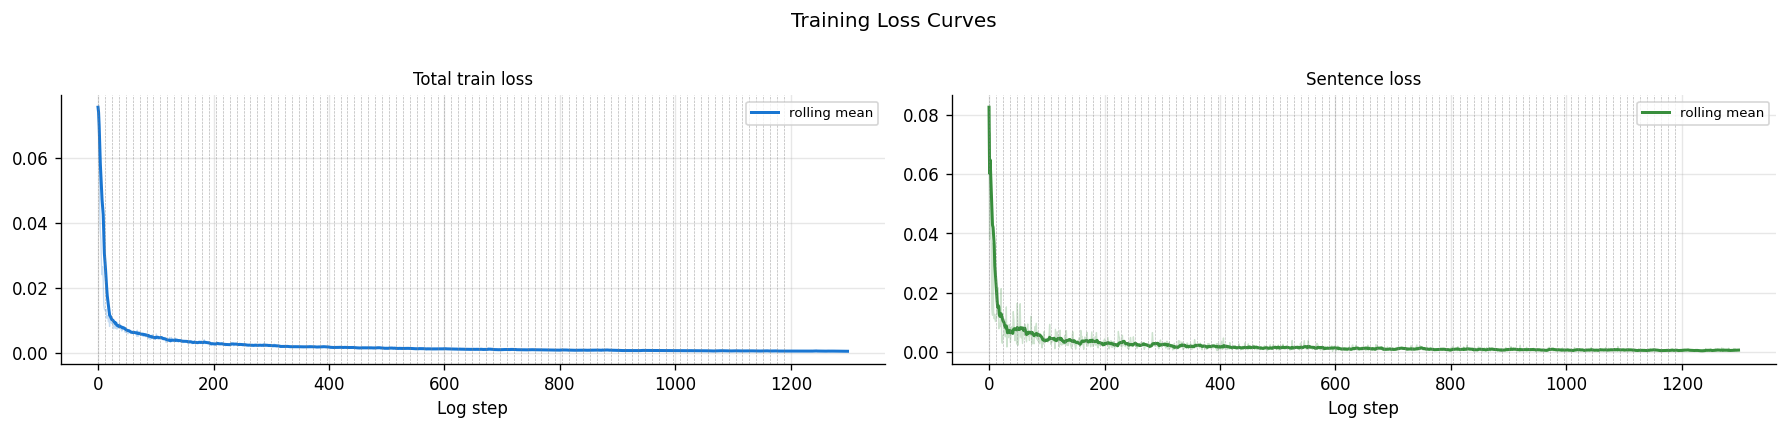

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))

loss_cols = [
    ("train_loss", "Total train loss",   "#1976d2"),
    ("loss_sent",  "Sentence loss",      "#388e3c"),
]

for ax, (col, title, colour) in zip(axes, loss_cols):
    s = train[col].dropna()
    if s.empty:
        ax.set_visible(False)
        continue
    # Rolling mean for readability
    smooth = s.rolling(10, min_periods=1).mean()
    ax.plot(s.index, s.values,  color=colour, alpha=0.25, linewidth=0.8)
    ax.plot(s.index, smooth,    color=colour, linewidth=1.8, label="rolling mean")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Log step")
    ax.legend(fontsize=8)

    # Epoch separators
    epoch_starts = train.groupby("epoch")["global_step"].min()
    for es in epoch_starts:
        ax.axvline(es, color="grey", linewidth=0.4, linestyle="--", alpha=0.6)

fig.suptitle("Training Loss Curves", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3 · Validation loss & correlation curves

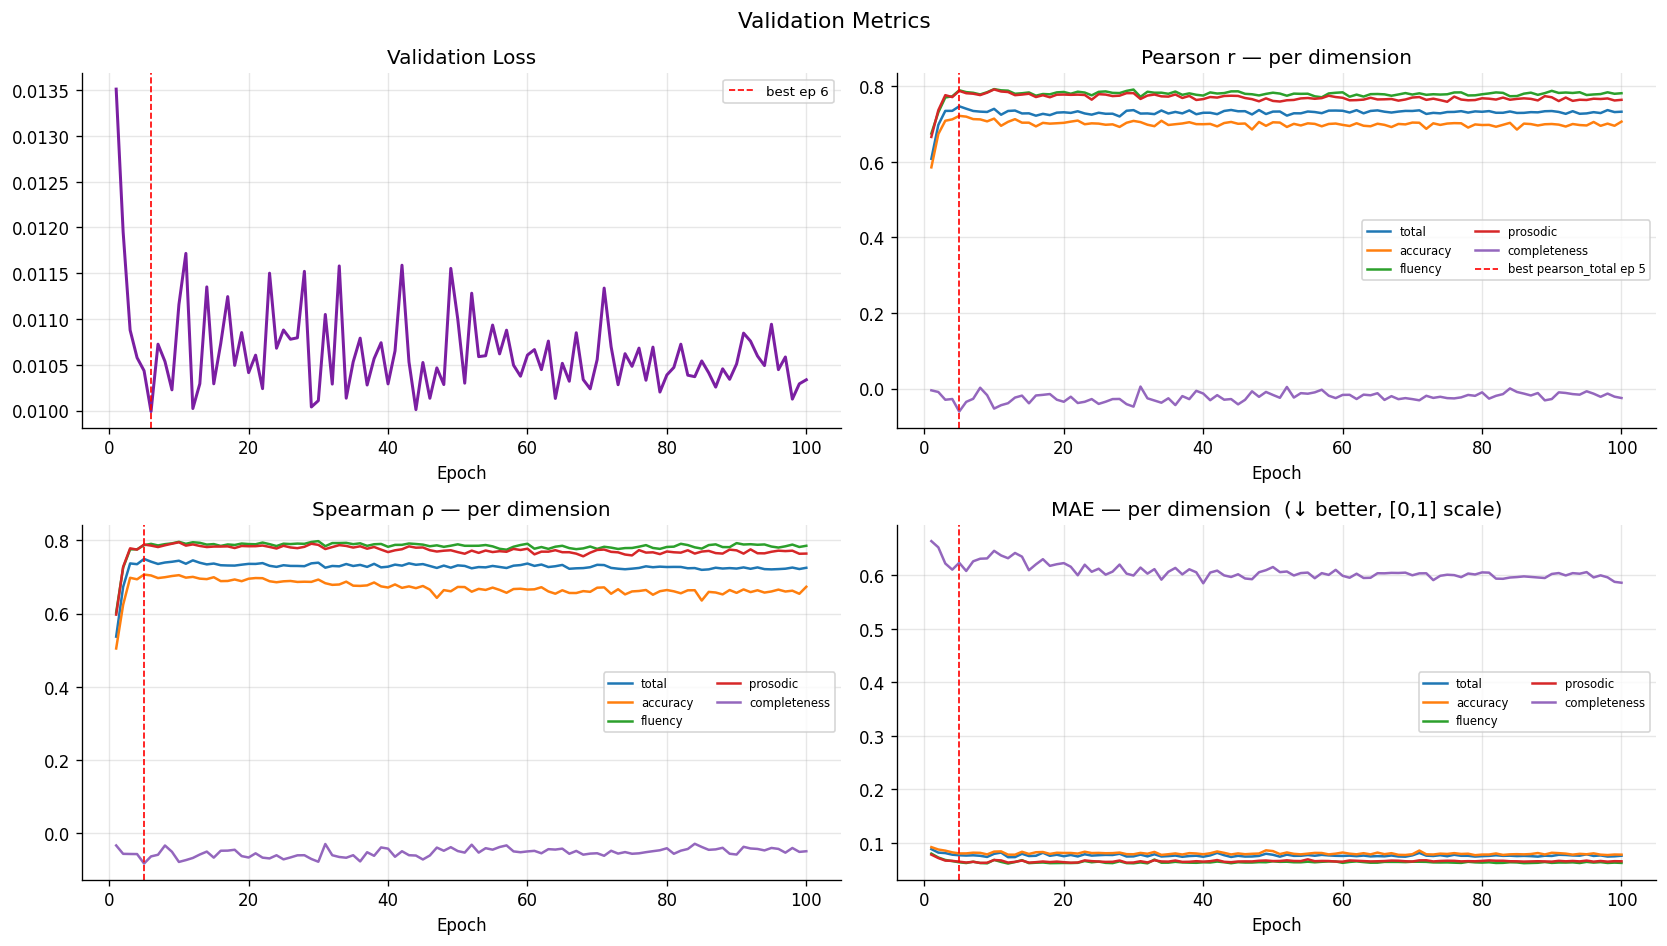


Best epoch (pearson_total): 5


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

epochs = val["epoch"]

# ── Val loss ──────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs, val["val_loss"], color="#7b1fa2", linewidth=1.8)
best_loss_ep = val.loc[val["val_loss"].idxmin(), "epoch"]
ax.axvline(best_loss_ep, color="red", linestyle="--", linewidth=1, label=f"best ep {best_loss_ep:.0f}")
ax.set_title("Validation Loss")
ax.set_xlabel("Epoch")
ax.legend(fontsize=8)

# ── Pearson per dim ───────────────────────────────────────────────────────
ax = axes[0, 1]
colours = plt.cm.tab10.colors
for i, dim in enumerate(SENT_DIMS):
    col = f"pearson_{dim}"
    if col in val:
        ax.plot(epochs, val[col], label=dim, color=colours[i], linewidth=1.5)
best_ep = val.loc[val[BEST_METRIC].idxmax(), "epoch"]
ax.axvline(best_ep, color="red", linestyle="--", linewidth=1, label=f"best {BEST_METRIC} ep {best_ep:.0f}")
ax.set_title("Pearson r — per dimension")
ax.set_xlabel("Epoch")
ax.legend(fontsize=7, ncol=2)

# ── Spearman per dim ──────────────────────────────────────────────────────
ax = axes[1, 0]
for i, dim in enumerate(SENT_DIMS):
    col = f"spearman_{dim}"
    if col in val:
        ax.plot(epochs, val[col], label=dim, color=colours[i], linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", linewidth=1)
ax.set_title("Spearman ρ — per dimension")
ax.set_xlabel("Epoch")
ax.legend(fontsize=7, ncol=2)

# ── MAE per dim ───────────────────────────────────────────────────────────
ax = axes[1, 1]
for i, dim in enumerate(SENT_DIMS):
    col = f"mae_{dim}"
    if col in val:
        ax.plot(epochs, val[col], label=dim, color=colours[i], linewidth=1.5)
ax.axvline(best_ep, color="red", linestyle="--", linewidth=1)
ax.set_title("MAE — per dimension  (↓ better, [0,1] scale)")
ax.set_xlabel("Epoch")
ax.legend(fontsize=7, ncol=2)

fig.suptitle("Validation Metrics", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest epoch ({BEST_METRIC}): {best_ep:.0f}")

## 4 · Per-dimension radar at best epoch

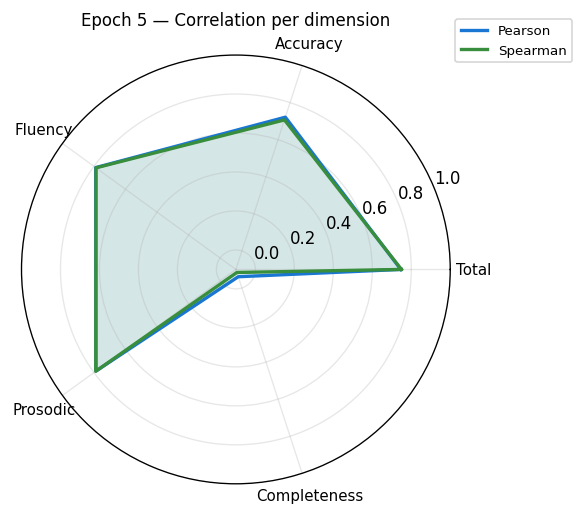

In [ ]:
best_row = val.loc[val[BEST_METRIC].idxmax()]

pearson_vals  = [best_row.get(f"pearson_{d}",  np.nan) for d in SENT_DIMS]
spearman_vals = [best_row.get(f"spearman_{d}", np.nan) for d in SENT_DIMS]

# Radar chart
N      = len(SENT_DIMS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

for vals, label, colour in [
    (pearson_vals,  "Pearson",  "#1976d2"),
    (spearman_vals, "Spearman", "#388e3c"),
]:
    v = vals + vals[:1]
    ax.plot(angles, v, color=colour, linewidth=2, label=label)
    ax.fill(angles, v, color=colour, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([d.capitalize() for d in SENT_DIMS], fontsize=9)
ax.set_ylim(-0.1, 1.0)
ax.set_title(f"Epoch {best_ep:.0f} — Correlation per dimension", pad=18, fontsize=10)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

## 5 · Convergence summary table

In [ ]:
from IPython.display import display, HTML

# Best row per key metric
summary_metrics = {
    "Best pearson_total  ↑": ("pearson_total",  "max"),
    "Best spearman_total ↑": ("spearman_total", "max"),
    "Lowest val_loss     ↓": ("val_loss",       "min"),
    "Lowest mae_total    ↓": ("mae_total",       "min"),
}

rows_html = ""
for label, (col, mode) in summary_metrics.items():
    if col not in val:
        continue
    idx = val[col].idxmax() if mode == "max" else val[col].idxmin()
    row = val.loc[idx]
    rows_html += (
        f"<tr>"
        f"<td style='padding:4px 12px'>{label}</td>"
        f"<td style='padding:4px 12px;font-weight:bold'>{row[col]:.4f}</td>"
        f"<td style='padding:4px 12px'>epoch {row['epoch']:.0f}</td>"
        f"<td style='padding:4px 12px'>pearson_total={row.get('pearson_total', float('nan')):.4f}</td>"
        f"<td style='padding:4px 12px'>mae_total={row.get('mae_total', float('nan')):.4f}</td>"
        f"</tr>"
    )

display(HTML(
    "<h4>Convergence Summary</h4>"
    "<table style='border-collapse:collapse;font-size:0.9em'>"
    "<thead><tr>"
    "<th style='padding:4px 12px;text-align:left'>Metric</th>"
    "<th style='padding:4px 12px;text-align:left'>Value</th>"
    "<th style='padding:4px 12px;text-align:left'>Epoch</th>"
    "<th style='padding:4px 12px;text-align:left'>pearson_total @ that epoch</th>"
    "<th style='padding:4px 12px;text-align:left'>mae_total @ that epoch</th>"
    "</tr></thead>"
    f"<tbody>{rows_html}</tbody></table>"
))

Metric,Value,Epoch,pearson_total @ that epoch,mae_total @ that epoch
Best pearson_total ↑,0.7467,epoch 5,pearson_total=0.7467,mae_total=0.0767
Best spearman_total ↑,0.7494,epoch 5,pearson_total=0.7467,mae_total=0.0767
Lowest val_loss ↓,0.0100,epoch 6,pearson_total=0.7402,mae_total=0.0761
Lowest mae_total ↓,0.0731,epoch 12,pearson_total=0.7343,mae_total=0.0731


## 6 · Full metrics at best epoch

In [ ]:
best_row = val.loc[val[BEST_METRIC].idxmax()].copy()

rows_html = ""
for dim in SENT_DIMS:
    p  = best_row.get(f"pearson_{dim}",  float("nan"))
    sp = best_row.get(f"spearman_{dim}", float("nan"))
    ma = best_row.get(f"mae_{dim}",      float("nan"))
    rm = best_row.get(f"rmse_{dim}",     float("nan"))

    def _bar(v, lo=-1, hi=1, reverse=False):
        pct = max(0, min(1, (v - lo) / (hi - lo))) * 100
        if reverse: pct = 100 - pct
        c = "#4caf50" if pct >= 60 else "#ff9800" if pct >= 30 else "#f44336"
        return (f"<div style='display:flex;align-items:center;gap:5px'>"
                f"<div style='width:80px;background:#eee;border-radius:3px;height:8px'>"
                f"<div style='width:{pct:.0f}%;background:{c};height:8px;border-radius:3px'></div>"
                f"</div><span>{v:.4f}</span></div>")

    rows_html += (
        f"<tr>"
        f"<td style='padding:4px 10px;font-weight:500'>{dim.capitalize()}</td>"
        f"<td style='padding:4px 10px'>{_bar(p)}</td>"
        f"<td style='padding:4px 10px'>{_bar(sp)}</td>"
        f"<td style='padding:4px 10px'>{_bar(ma, 0, 0.5, reverse=True)}</td>"
        f"<td style='padding:4px 10px'>{rm:.4f}</td>"
        f"</tr>"
    )

display(HTML(
    f"<h4>Best Epoch {best_row['epoch']:.0f} — Full Breakdown</h4>"
    "<table style='border-collapse:collapse;font-size:0.88em'>"
    "<thead><tr>"
    "<th style='padding:4px 10px'>Dim</th>"
    "<th style='padding:4px 10px'>Pearson ↑</th>"
    "<th style='padding:4px 10px'>Spearman ↑</th>"
    "<th style='padding:4px 10px'>MAE ↓</th>"
    "<th style='padding:4px 10px'>RMSE ↓</th>"
    "</tr></thead>"
    f"<tbody>{rows_html}</tbody></table>"
))

Dim,Pearson ↑,Spearman ↑,MAE ↓,RMSE ↓
Total,0.7467,0.7494,0.0767,0.1108
Accuracy,0.7213,0.7067,0.0801,0.1128
Fluency,0.7889,0.7872,0.0635,0.0902
Prosodic,0.7874,0.7888,0.0647,0.0928
Completeness,-0.0606,-0.0836,0.6232,0.6259


## 7 · Loss decomposition heatmap (epoch × loss component)

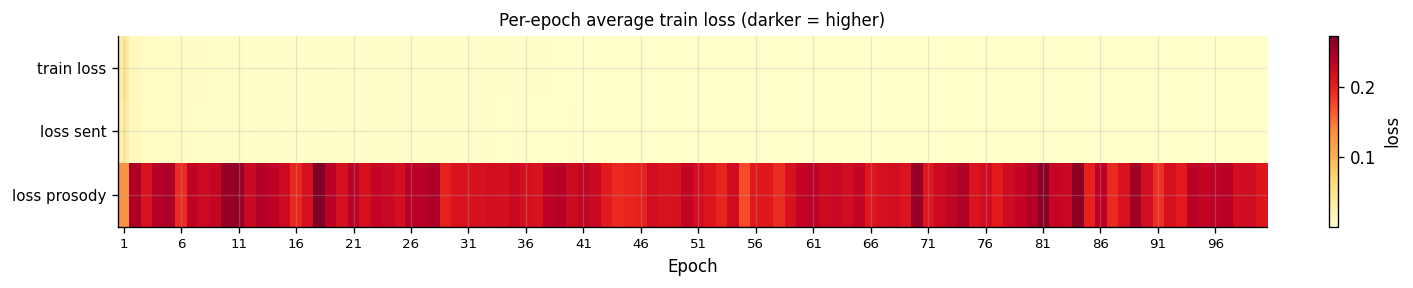

In [ ]:
# Average train losses per epoch
loss_cols = [c for c in ["train_loss", "loss_sent", "loss_prosody"] if c in train.columns]
epoch_avg = train.groupby("epoch")[loss_cols].mean()

fig, ax = plt.subplots(figsize=(12, 2.5))
im = ax.imshow(
    epoch_avg.T.values,
    aspect="auto", cmap="YlOrRd",
    interpolation="nearest",
)
ax.set_yticks(range(len(loss_cols)))
ax.set_yticklabels([c.replace("_", " ") for c in loss_cols], fontsize=9)
ax.set_xlabel("Epoch")
ax.set_xticks(range(0, len(epoch_avg), max(1, len(epoch_avg)//20)))
ax.set_xticklabels(epoch_avg.index[::max(1, len(epoch_avg)//20)].astype(int), fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.02, label="loss")
ax.set_title("Per-epoch average train loss (darker = higher)", fontsize=10)
plt.tight_layout()
plt.show()

## 8 · Pearson improvement vs epoch 1 (ΔPearson)

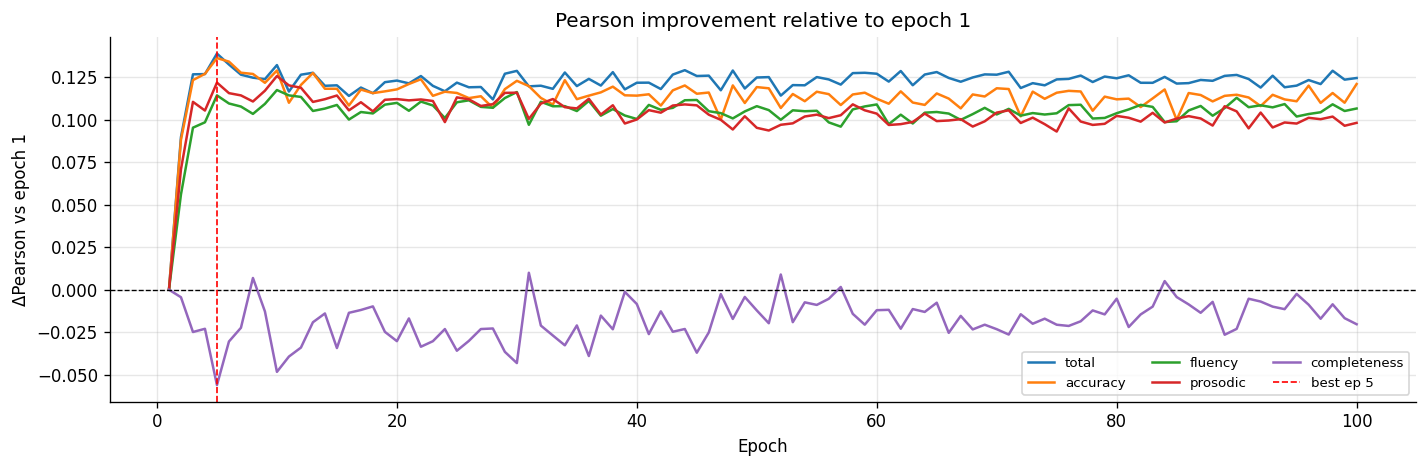

In [ ]:
base = val[val["epoch"] == val["epoch"].min()].iloc[0]

fig, ax = plt.subplots(figsize=(12, 4))
for i, dim in enumerate(SENT_DIMS):
    col = f"pearson_{dim}"
    if col not in val: continue
    delta = val[col] - float(base[col])
    ax.plot(val["epoch"], delta, label=dim, color=colours[i], linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(best_ep, color="red", linewidth=1, linestyle="--", label=f"best ep {best_ep:.0f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("ΔPearson vs epoch 1")
ax.set_title("Pearson improvement relative to epoch 1")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 9 · Top-10 epochs by pearson_total

In [ ]:
metric_cols = (
    ["epoch", "val_loss"]
    + [f"pearson_{d}"  for d in SENT_DIMS]
    + [f"spearman_{d}" for d in SENT_DIMS]
    + [f"mae_{d}"      for d in SENT_DIMS]
)
metric_cols = [c for c in metric_cols if c in val.columns]

top10 = (
    val[metric_cols]
    .sort_values("pearson_total", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1  # rank from 1

display(
    top10.style
    .format({c: "{:.4f}" for c in top10.columns if c != "epoch"})
    .background_gradient(subset=["pearson_total"], cmap="Greens")
    .background_gradient(subset=["mae_total"],     cmap="Reds_r")
    .set_caption("Top-10 epochs by pearson_total")
)

,epoch,val_loss,pearson_total,pearson_accuracy,pearson_fluency,pearson_prosodic,pearson_completeness,spearman_total,spearman_accuracy,spearman_fluency,spearman_prosodic,spearman_completeness,mae_total,mae_accuracy,mae_fluency,mae_prosodic,mae_completeness
1,5,0.0104,0.7467,0.7213,0.7889,0.7874,-0.0606,0.7494,0.7067,0.7872,0.7888,-0.0836,0.0767,0.0801,0.0635,0.0647,0.6232
2,6,0.0100,0.7402,0.7193,0.7841,0.7812,-0.0349,0.7420,0.7043,0.7907,0.7859,-0.0641,0.0761,0.0802,0.0622,0.0631,0.6079
3,10,0.0112,0.7399,0.7140,0.7920,0.7913,-0.0528,0.7446,0.7050,0.7963,0.7950,-0.0792,0.0794,0.0835,0.0681,0.0678,0.6455
4,44,0.0100,0.7369,0.7052,0.7860,0.7746,-0.0276,0.7335,0.6695,0.7903,0.7803,-0.0617,0.0735,0.0782,0.0618,0.0638,0.5967
5,48,0.0103,0.7367,0.7053,0.7754,0.7598,-0.0217,0.7312,0.6642,0.7825,0.7719,-0.0486,0.0755,0.0799,0.0638,0.0664,0.6055
6,98,0.0101,0.7366,0.7008,0.7837,0.7674,-0.0131,0.7259,0.6626,0.7887,0.7720,-0.0410,0.0743,0.0771,0.0623,0.0647,0.5960
7,30,0.0101,0.7365,0.7080,0.7909,0.7815,-0.0476,0.7392,0.6930,0.7982,0.7879,-0.0787,0.0746,0.0785,0.0617,0.0632,0.5994
8,62,0.0104,0.7364,0.7018,0.7776,0.7630,-0.0274,0.7342,0.6722,0.7820,0.7694,-0.0555,0.0750,0.0785,0.0652,0.0664,0.6028
9,71,0.0113,0.7360,0.7031,0.7810,0.7711,-0.0308,0.7327,0.6717,0.7827,0.7751,-0.0623,0.0811,0.0855,0.0646,0.0672,0.6034
10,65,0.0105,0.7358,0.7006,0.7791,0.7648,-0.0121,0.7331,0.6638,0.7854,0.7678,-0.0428,0.0751,0.0817,0.0629,0.0655,0.6036
